# **PDIPy Módulo 2 - Aula 10 - Lendo e Plotando uma Imagem**

In [1]:
# Primeiro passo é instalar bibliotecas que não estão no Colab.

!pip install gdal
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 28.3 MB/s eta 0:00:00


In [2]:
!pip install spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.3 MB/s eta 0:00:00


**TIFF FILE:** faz a leitura de todo arquivo tiff

In [3]:
import tifffile as tif # Leitura do tif
import matplotlib.pyplot as plt # Plotar as imagens
from spectral import imshow

In [4]:
img = tif.imread('/content/drive/MyDrive/arcprojects/PDIPy_Curso/Img_L7/L71221071_07120010720_DN.tif')

In [5]:
# Vamos checar as dimensões da imagem
img.shape  # Possui 1233 linhas, por 1520 colunas e 6 bandas

(1233, 1520, 6)

É importante perceber que o tifffile faz a leitura da imagem TIFF, porém sem mostrar as coordenadas da imagem. O que é mostrado é o índice das linhas e colunas como se fosse uma matriz ordinária.

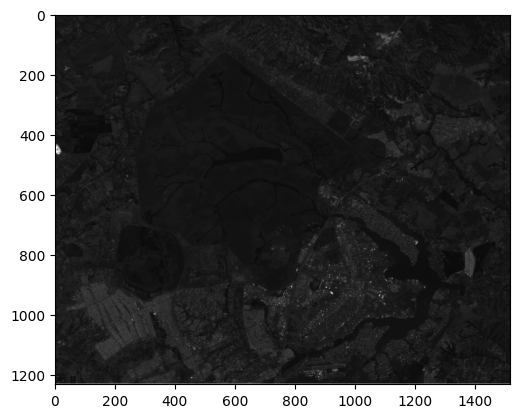

In [6]:
# Vamos visualizar bandas separadamente. Portanto, é necessário dimensionalizar o plot.
# Chamar a variável img e exibir todas as linhas (:), todas as colunas (:) e apenas a banda 1 (0) - AZUL
plt.imshow(img[:,:,0], cmap='Greys_r') # é preciso colocar uma rampa de cores (níveis de cinza)

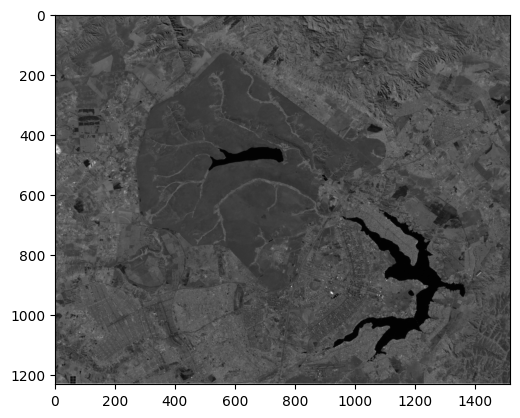

In [7]:
plt.imshow(img[:,:,3], cmap='Greys_r') # Índice 3 é Banda 4 - INFRARED

ImageView object:
  Display bands       :  [0, 3.0, 5]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(40.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(1.0), np.float64(255.0)]

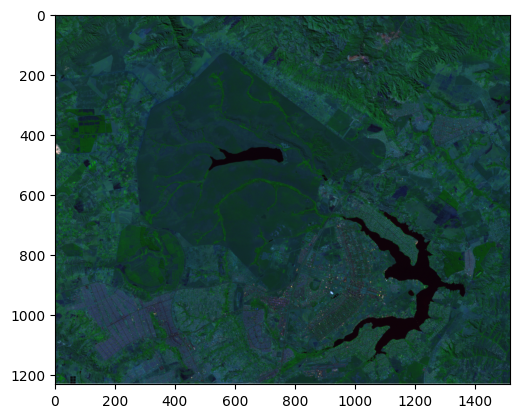

In [8]:
# Vamos plotar em RBG. No entanto, o método "imshow" do plt não aceita composição de bandas como visto anteriormente
# Portanto, vamos utilizar o médoto de mesmo nome, porém da biblioteca spectral
imshow(img) # Chamando apenas a imagem, a composição RGB é aleatória como visto abaixo (Display bands:  [0, 3.0, 5])

ImageView object:
  Display bands       :  (2, 1, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(4.0), np.float64(255.0)]
    G: [np.float64(13.0), np.float64(255.0)]
    B: [np.float64(40.0), np.float64(255.0)]

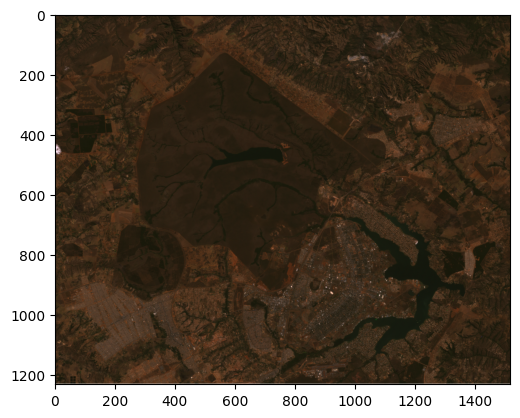

In [9]:
imshow(img, bands=(2,1,0))

ImageView object:
  Display bands       :  (2, 3, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(4.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(40.0), np.float64(255.0)]

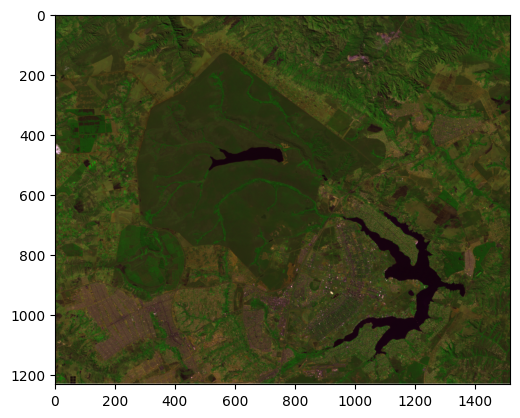

In [10]:
imshow(img, bands=(2,3,0))

**GDAL**

In [11]:
from osgeo import gdal
import numpy as np

In [12]:
img2 = gdal.Open('/content/drive/MyDrive/arcprojects/PDIPy_Curso/Img_L7/L71221071_07120010720_DN.tif')

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [13]:
# Vamos ver que tipo de objeto é o img2
print(img2) # Este objeto não está na estrutura array originalmente. Seré preciso converter img2 para esse tipo de estrutura

<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x7959c99e31b0> >


In [14]:
# Para converter para array basta passar para uma nova variável como array:
img3 = img2.ReadAsArray()

In [15]:
# Agora vamos checar a quantidade de linhas e colunas:
img3.shape  # observa-se que a ordem das dimensões da matriz mudou em relação ao TIFFFILE. Agora é Banda, Linha e Coluna

(6, 1233, 1520)

ImageView object:
  Display bands       :  [0]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(12.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(12.0), np.float64(255.0)]

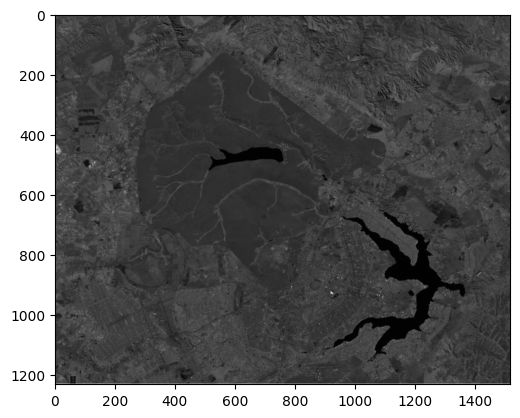

In [16]:
# Dessa forma o imshow deve ser configurado nessa nova ordem:
imshow(img3[3,:,:]) # Foi plotado a banda IR

In [17]:
# No entanto, pode-se alterar a ordem das dimensões conforme o padrão estabelecido (linha, coluna, banda)
img3 = img3.swapaxes(0,1) # Nesta configuração, estou trocando bandas com linhas

In [18]:
img3 = img3.swapaxes(1,2) # Agora trocando bandas com colunas

In [19]:
# Feito a troca, vamos checar:
img3.shape # Tudo certo agora: sequência linhas, colunas e bandas.

(1233, 1520, 6)

ImageView object:
  Display bands       :  [0]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(12.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(12.0), np.float64(255.0)]

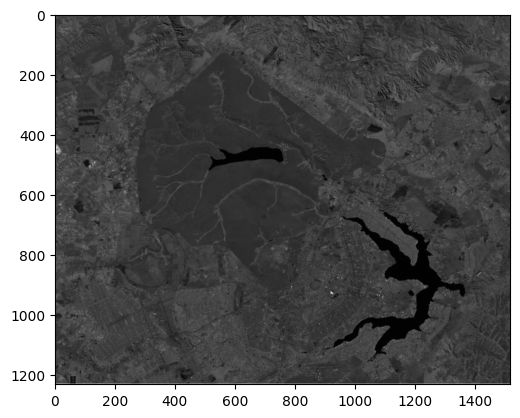

In [20]:
imshow(img3[:,:,3])

ImageView object:
  Display bands       :  (2, 3, 1)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(4.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(13.0), np.float64(255.0)]

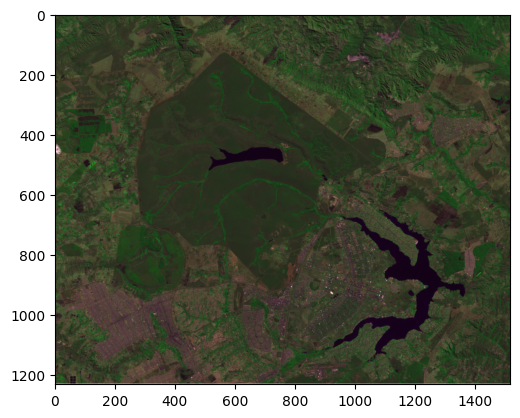

In [21]:
# Fazendo uma composição colorida:
imshow(img3, bands=(2,3,1))

In [22]:
from binascii import b2a_base64
# TRABALHANDO COM BANDAS INDIVIDUALMENTE
# Pode-se carregar cada banda em variáveis separadas.
# No GDAL as bandas começam no índice 1 e não 0 como o usual no Python

b1 = img2.GetRasterBand(1).ReadAsArray()
b2 = img2.GetRasterBand(2).ReadAsArray()
b3 = img2.GetRasterBand(3).ReadAsArray()
b4 = img2.GetRasterBand(4).ReadAsArray()
b5 = img2.GetRasterBand(5).ReadAsArray()
b6 = img2.GetRasterBand(6).ReadAsArray()

ImageView object:
  Display bands       :  [0]
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(40.0), np.float64(255.0)]
    G: [np.float64(40.0), np.float64(255.0)]
    B: [np.float64(40.0), np.float64(255.0)]

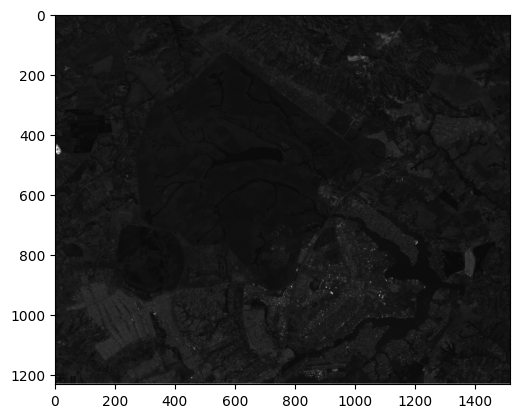

In [23]:
imshow(b1)

In [24]:
# Existe um método da biblioteca NUMPY que faz a composição colorida com variáveis dedicadas para cada banda
stack = np.dstack((b1,b2,b4))

In [25]:
# Verificando o shape do stack
stack.shape # Padráo linha, coluna, banda

(1233, 1520, 3)

ImageView object:
  Display bands       :  (1, 2, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(13.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(40.0), np.float64(255.0)]

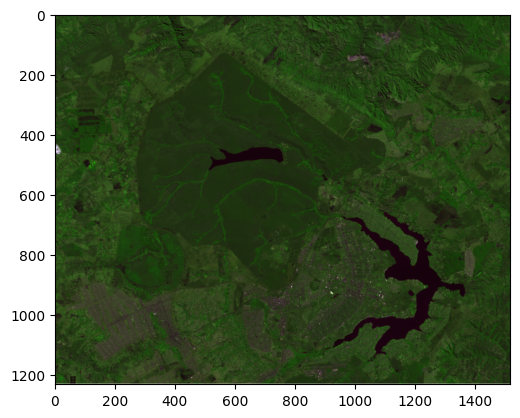

In [26]:
# Para visualizer é o mesmo método
imshow(stack, (1, 2, 0)) # b2 no Red, b4 no Green, b1 no Blue

# Como é um ARRAY, a visualização não tem coordenadas, apenas o índice de linhas e colunas

**RASTERIO**

In [27]:
import rasterio
from rasterio.plot import show

In [28]:
rst = rasterio.open('/content/drive/MyDrive/arcprojects/PDIPy_Curso/Img_L7/L71221071_07120010720_DN.tif')

In [29]:
print(rst)  # é um dataset reader. Portanto, para visualizar terá que ser feito as mesmas conversões que o GDAL.

<open DatasetReader name='/content/drive/MyDrive/arcprojects/PDIPy_Curso/Img_L7/L71221071_07120010720_DN.tif' mode='r'>


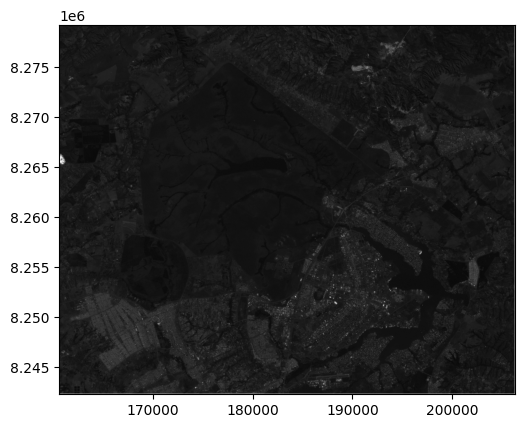

<Axes: >

In [30]:
# No entanto, o rasterio tem um módulo próprio para visualização: plot - show
show(rst, cmap='Greys_r') # Este método faz a leitura das coordenadas da imagem, que neste caso são coordenadas UTM.
# Como não foi configurado a banda para visualização, o default é mostrar a banda 1 - Azul

In [31]:
# Para converter as bandas em arquivos separados como NUMPY ARRAY, basta aplicar o método read()
b1 = rst.read(1)
b2 = rst.read(2)
b3 = rst.read(3)
b4 = rst.read(4)
b5 = rst.read(5)
b6 = rst.read(6)

In [32]:
stack2 = np.dstack((b1,b2,b4))

ImageView object:
  Display bands       :  (1, 2, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(13.0), np.float64(255.0)]
    G: [np.float64(12.0), np.float64(255.0)]
    B: [np.float64(40.0), np.float64(255.0)]

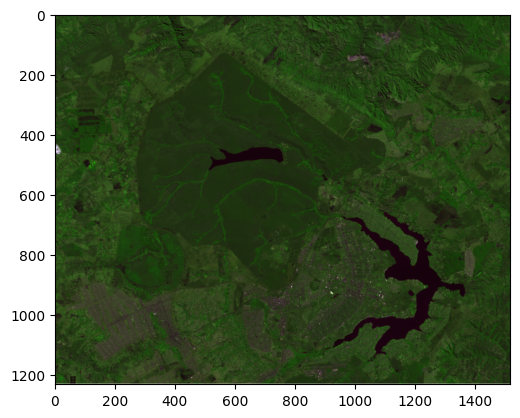

In [33]:
imshow(stack2, (1, 2, 0))